In [1]:
!pip install datasets

In [2]:
import datasets

c:\Users\ADMIN\anaconda3\envs\tracking-barbell-exercises\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('vi.txt', sep='\t', header=None, names=['sentence'])
df['list'] = df['sentence'].str.split()
df['list']

0                       [Chiều, nay, vào, lúc, 5:00, giờ...]
1                                                 [Il, Duce]
2          [-, Benito, Mussolini, sẽ, nói, chuyện, với, q...
3          [Các, bạn, được, lệnh, phải, bật, radio, để, n...
4          [Tất, cả, những, ai, có, máy, phát, thanh, và,...
                                 ...                        
3279727    [Anh, lại, nằm, mơ, rồi,, cấm, đánh, thức, anh...
3279728                                             [Ồ, dê!]
3279729                                 [Luân, phiên, nhau.]
3279730             [Luân, phiên, nhau,, luân, phiên, nhau.]
3279731                                             [Ồ, dê!]
Name: list, Length: 3279732, dtype: object

In [36]:
# keep only rows whose token list has at least one element and fewer than 2000
df = df[df['list'].apply(lambda x: 0 < len(x) < 25)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3243898 entries, 0 to 3279731
Data columns (total 2 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   sentence  object
 1   list      object
dtypes: object(2)
memory usage: 74.2+ MB


([<matplotlib.axis.XTick at 0x25599741370>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23'),
  Text(24, 0, '24'),
  Text(25, 0, '25'),
  Text(26, 0, '26'),
  Text(27, 0, '27'),
  Text(28, 0, '28'),
  Text(29, 0, '29')])

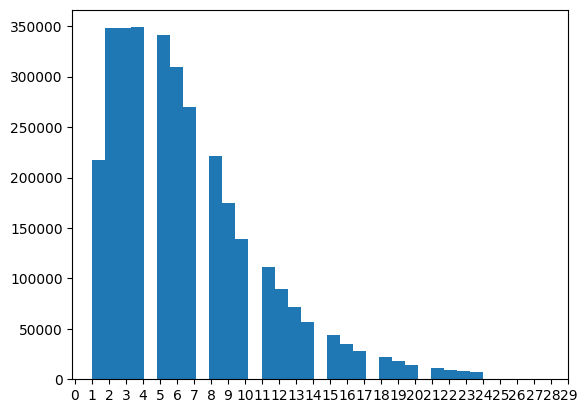

In [39]:
plt.hist([len(x) for x in df['list']], bins=30)
plt.xticks(range(0, 30))

In [38]:
df[df['list'].apply(lambda x: len(x)<6)].count()

sentence    1603740
list        1603740
dtype: int64

In [ ]:


# Bước 4: Lấy 10,000 mẫu dựa trên trọng số vừa tính
text_series = df.copy()

lengths = text_series.apply(lambda x: len(str(x).split()), axis=1)

# Bước 2: Đếm tần suất xuất hiện của từng độ dài trong toàn bộ 3 triệu mẫu
# map() sẽ gán tần suất tương ứng vào từng dòng
length_counts = lengths.map(lengths.value_counts())

# Bước 3: Tính trọng số (Xác suất nghịch đảo)
# Cộng thêm 1 khoảng nhỏ (vd: 1e-5) để tránh lỗi chia cho 0 nếu có
weights = 1.0 / (length_counts + 1e-5)

# Bước 4: Lấy 10,000 mẫu dựa trên trọng số vừa tính

weights

In [ ]:

smooth_sample = text_series.sample(n=10000, weights=weights, random_state=42)